In [1]:
%run eval.ipynb
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from utils import eval, visual, save, save_model
from model import Model
import warnings
warnings.filterwarnings('ignore')
from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import CRPS
import warnings
from sklearn.model_selection import cross_validate, KFold


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_excel('data/6_air_1013.xlsx', sheet_name='Sheet1', index_col=0)
data.columns = data.columns.str.strip() 

feature_names = ["CurrentDensity", "O2", "CO2"]
X = data[feature_names].to_numpy()
y = data["overpotential"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("train:", X_train_scaled.shape)  # -> (n, 3)
print("test:", X_test_scaled.shape)

train: (476, 3)
test: (119, 3)


In [5]:
with open('model/scaler_6_air.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# NGBoost

nGBoost train: 
 r2: 0.9072587863215211  rmse: 0.12806175020445493  mse:0.016399811865428212 error_ratio:8.63% mae:0.08112475908931951
nGBoost test: 
 r2: 0.8664687521789614  rmse: 0.14511064451621644 mse:0.021057099151911736 error_ratio:9.84% mae:0.10454982735565048
save result successful！


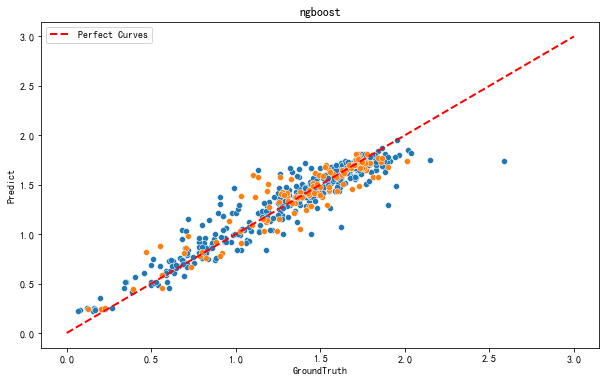


【CV-5】  R²=0.811782±0.083330 | MAE=0.114505±0.008119 | RMSE=0.176770±0.026910


In [3]:
ngb = NGBRegressor(
    Dist=Normal,      
    Score=CRPS,       
    n_estimators=200,
    learning_rate=0.2,
    verbose=False,
    random_state=2025,
)


model = Model(ngb, X_train, X_test, y_train, y_test, 'nGBoost', '6_air_1013')


visual(model, 'ngboost', X_train, X_test, y_train, y_test)

kf = KFold(n_splits=5, shuffle=True, random_state=43)

scoring = {
    'r2': make_scorer(r2_score),
    'mae': make_scorer(mean_absolute_error),
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

cv_results = cross_validate(
    ngb, X_train, y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=False
)

r2_mean,  r2_std  = cv_results['test_r2'].mean(),  cv_results['test_r2'].std(ddof=1)
mae_mean, mae_std = cv_results['test_mae'].mean(), cv_results['test_mae'].std(ddof=1)
rmse_mean,rmse_std= cv_results['test_rmse'].mean(),cv_results['test_rmse'].std(ddof=1)

print(f"\n【CV-{kf.get_n_splits()}】  "
      f"R²={r2_mean:.6f}±{r2_std:.6f} | "
      f"MAE={mae_mean:.6f}±{mae_std:.6f} | "
      f"RMSE={rmse_mean:.6f}±{rmse_std:.6f}")

In [6]:
save_model(ngb, 'NGBoost_6_air')

save NGBoost_6_air model successful


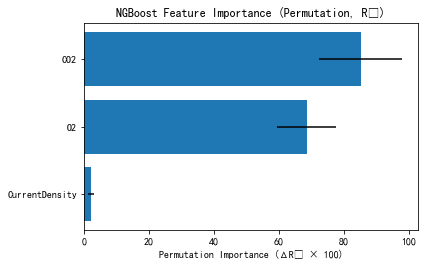

=== Permutation Importance (ΔR²) ===
CO2              0.8508 ± 0.1266  (85.08%)
O2               0.6852 ± 0.0906  (68.52%)
CurrentDensity   0.0223 ± 0.0090  (2.23%)


In [4]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

def as_ngb_estimator(m):
    if hasattr(m, "pred_dist") and hasattr(m, "predict"):
        return m
    if hasattr(m, "named_steps") and "ngboost" in m.named_steps:
        return m.named_steps["ngboost"]
    for attr in ("estimator", "model", "reg", "regressor", "clf", "learner"):
        if hasattr(m, attr):
            mm = getattr(m, attr)
            if hasattr(mm, "pred_dist") and hasattr(mm, "predict"):
                return mm
    raise RuntimeError("error")

est = as_ngb_estimator(ngb)

feature_names = ["CurrentDensity", "O2", "CO2"]

res = permutation_importance(
    estimator=est,
    X=X_test,
    y=y_test.ravel(),
    scoring="r2",
    n_repeats=30,
    random_state=2025
)

imp_mean = res.importances_mean
imp_std  = res.importances_std
order = np.argsort(imp_mean)  

plt.figure(figsize=(6, 3.8))
plt.barh(np.array(feature_names)[order], imp_mean[order]*100, xerr=imp_std[order]*100)
plt.xlabel("Permutation Importance (ΔR² × 100)")
plt.title("NGBoost Feature Importance (Permutation, R²)")
plt.tight_layout()
plt.show()

print("=== Permutation Importance (ΔR²) ===")
for name, m, s in zip(np.array(feature_names)[order[::-1]], imp_mean[order[::-1]], imp_std[order[::-1]]):
    print(f"{name:<15}  {m:.4f} ± {s:.4f}  ({m*100:.2f}%)")


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/119 [00:00<?, ?it/s]


===== mean|SHAP| ± std）=====
CO$_2$           0.166159±0.122031 (52.47%)
O$_2$            0.114383±0.102002 (36.12%)
Current Density  0.036138±0.017326 (11.41%)


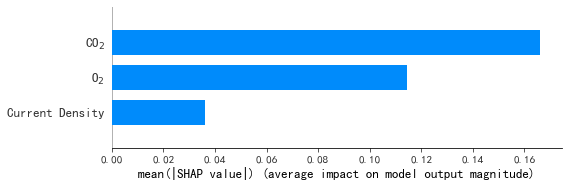

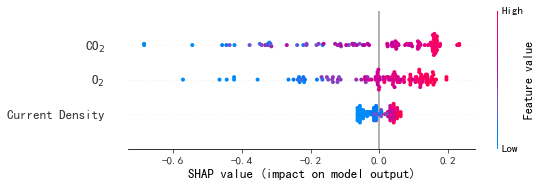

In [4]:

import numpy as np
import pandas as pd
import shap
import warnings
from sklearn.utils import check_random_state

warnings.filterwarnings("ignore")

feature_names = ["Current Density", "O$_2$", "CO$_2$"]
assert X_train.shape[1] == len(feature_names), "feature_names 数量需与 X_train 列数一致"

def to_frame(X, feature_names):
    if hasattr(X, "columns"):
        return X  
    else:
        return pd.DataFrame(X, columns=feature_names)

X_train_df = to_frame(X_train, feature_names)
X_test_df  = to_frame(X_test,  feature_names)

if not getattr(ngb, "fitted_", False):
    ngb.fit(X_train, y_train)

rng = check_random_state(0)
bg_size    = min(200, len(X_train_df))  
test_size  = min(200, len(X_test_df))   
nsamples   = 300                       

bg_idx   = rng.choice(len(X_train_df), size=bg_size, replace=False)
test_idx = rng.choice(len(X_test_df),  size=test_size,  replace=False)
X_bg     = X_train_df.iloc[bg_idx]
X_te_sub = X_test_df.iloc[test_idx]

f = lambda X: ngb.predict(X)

explainer = shap.KernelExplainer(f, X_bg, link="identity")
shap_values = explainer.shap_values(X_te_sub, nsamples=nsamples)  # (n_test, n_features)

abs_shap = np.abs(shap_values)
imp_mean = abs_shap.mean(axis=0)
imp_std  = abs_shap.std(axis=0, ddof=1)

imp_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_SHAP": imp_mean,
    "std_abs_SHAP": imp_std
}).sort_values("mean_abs_SHAP", ascending=False).reset_index(drop=True)

imp_df["contribution(%)"] = 100 * imp_df["mean_abs_SHAP"] / imp_df["mean_abs_SHAP"].sum()

print("\n===== mean|SHAP| ± std）=====")
for _, row in imp_df.iterrows():
    print(f"{row['feature']:<16s} {row['mean_abs_SHAP']:.6f}±{row['std_abs_SHAP']:.6f} "
          f"({row['contribution(%)']:.2f}%)")

shap.summary_plot(shap_values, X_te_sub, feature_names=feature_names, plot_type="bar")
shap.summary_plot(shap_values, X_te_sub, feature_names=feature_names)
